# 构造“宽表”

In [1]:
import pandas as pd

# 宽表数据
df_wide= pd.DataFrame(
    [
        ["A", 100, 120, 90],
        ["B", 80, 95, 110],
        ["C", 110, 105, 115],
    ],
    columns=["user", "Jan", "Feb", "Mar"]
)
print("宽表：")
df_wide


宽表：


,user,Jan,Feb,Mar
0,A,100,120,90
1,B,80,95,110
2,C,110,105,115


# “宽表” ->“长表”：melt()

In [2]:
df_long = df_wide.melt(
    id_vars="user",          # 保留不变的列
    value_vars=["Jan", "Feb", "Mar"],   # 需要展开的列
    var_name="month",        # 新“月份”列的名字
    value_name="sales"       # 新“销售额”列的名字
)

print("长表：")
df_long


长表：


,user,month,sales
0,A,Jan,100
1,B,Jan,80
2,C,Jan,110
3,A,Feb,120
4,B,Feb,95
5,C,Feb,105
6,A,Mar,90
7,B,Mar,110
8,C,Mar,115


# “长表”的主要作用之一：进行绘图

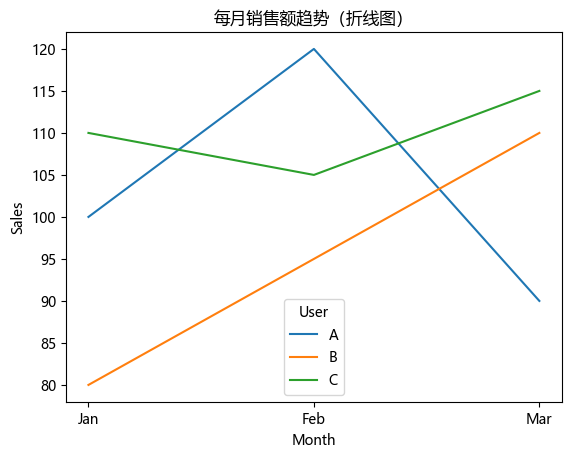

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# 下面的设置用于在图片上显示中文
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei'] # 微软雅黑（更好看）
plt.rcParams['axes.unicode_minus'] = False   # 解决负号显示成方块的问题

plt.figure()

sns.lineplot(data=df_long, x="month", y="sales", hue="user")

plt.title("每月销售额趋势（折线图）")
plt.ylabel("Sales")
plt.xlabel("Month")
plt.legend(title="User")
plt.show()

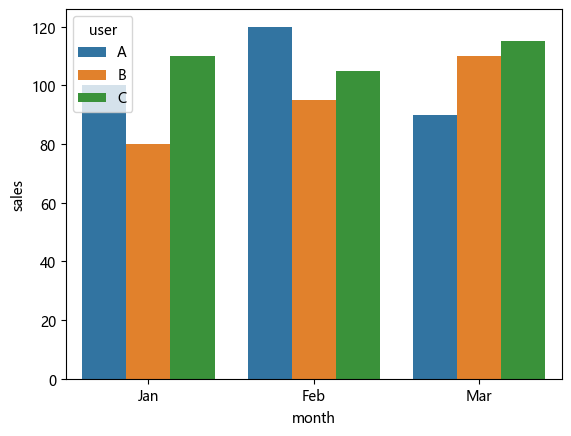

In [4]:
sns.barplot(data=df_long, x="month", y="sales", hue="user")
plt.show()

# “长表” -> “宽表”：pivot()

In [ ]:
df_wide2 = df_long.pivot(index="user", columns="month", values="sales").reset_index()

print("\n：pivot 转回宽表")
df_wide2

# 当“长表”有重复值的时候如何处理？

## 构造具有重复行的“长表”

In [ ]:
df_long_dupe = pd.concat([df_long, df_long.iloc[[0]]])  # 故意复制一行

print("\n故意制造重复后的长表：")
df_long_dupe

## 对重复行的数据如何处理？aggfunc

In [ ]:
df_wide_agg = df_long_dupe.pivot_table(
    index="user",
    columns="month",
    values="sales",
    aggfunc="sum"       # 可以改成 "mean"、"max"、"min"、"count" 等
).reset_index()

print("处理重复的行：")
df_wide_agg

# 总结

In [ ]:
# ==================== 总结：长 ↔ 宽 随时切换才是王道 ====================
print("\n总结：")
print("绘图、统计、建模 → 强烈建议用 长表（tidy data）")
print("透视报表、导出给领导、机器学习 → 用 宽表 最直观")
print("记住两行代码就够了：")
print("   宽 → 长：melt()")
print("   长 → 宽：pivot()  或  pivot_table()")